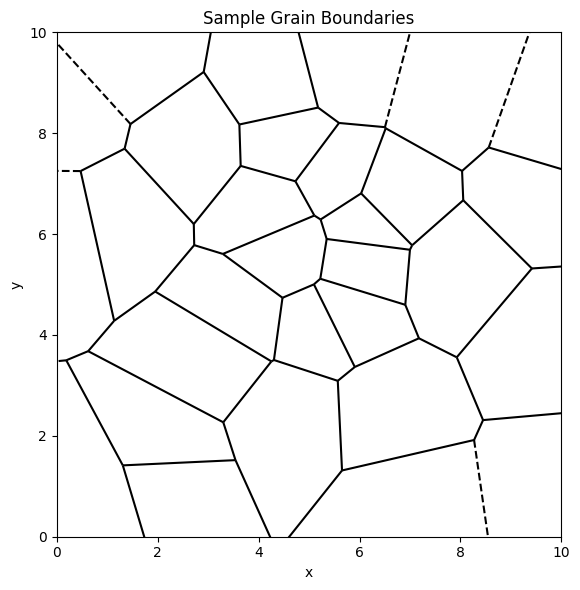

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# -----------------------------
# Parameters
# -----------------------------
np.random.seed(0)
n_grains = 30        # number of grains
domain_size = 10.0  # size of square domain

# -----------------------------
# Generate random grain centers
# -----------------------------
points = np.random.rand(n_grains, 2) * domain_size

# -----------------------------
# Compute Voronoi tessellation
# -----------------------------
vor = Voronoi(points)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Voronoi diagram (grain boundaries)
voronoi_plot_2d(
    vor,
    ax=ax,
    show_vertices=False,
    show_points = False,
    line_colors='black',
    line_width=1.5,
    line_alpha=1.0,
    point_size=10
)

# Formatting
ax.set_xlim(0, domain_size)
ax.set_ylim(0, domain_size)
ax.set_aspect('equal')
ax.set_title("Sample Grain Boundaries")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()


/tmp/ipykernel_31492/1106369740.py:190: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_grains)


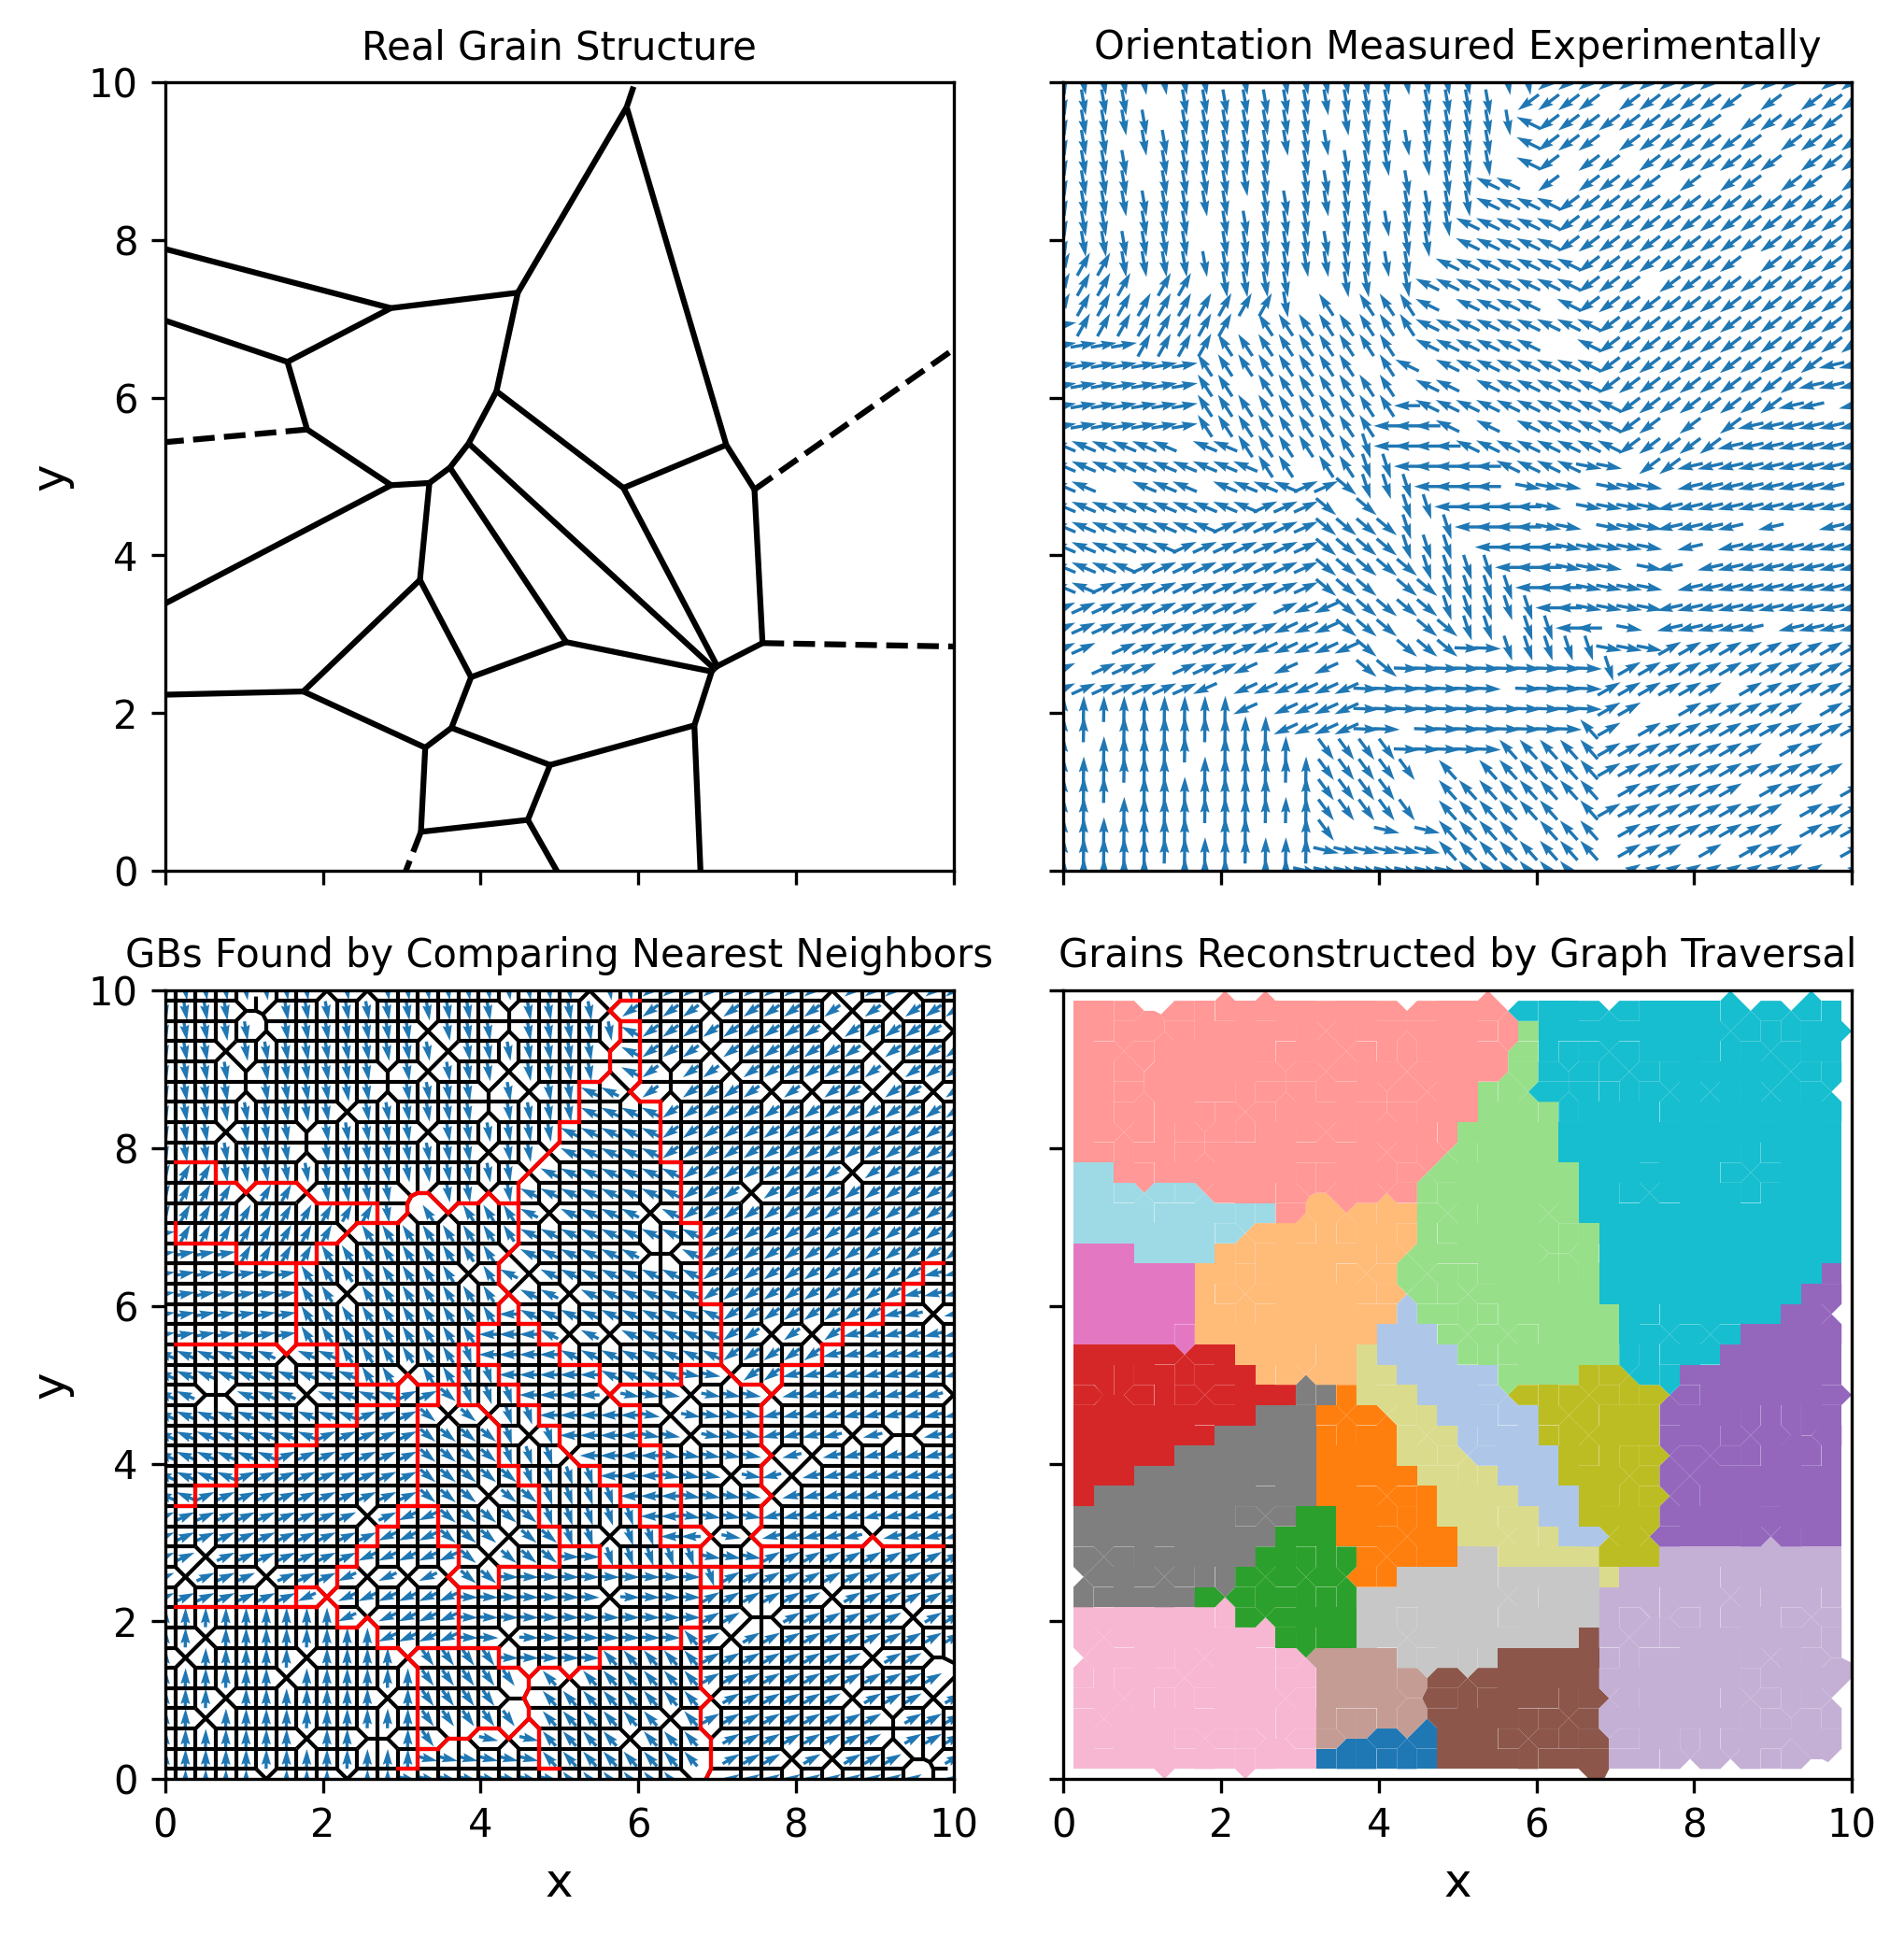

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, cKDTree

# -----------------------------
# Parameters
# -----------------------------
np.random.seed(2)
n_grains = 20
domain_size = 10.0
grid_points = 40
min_misorientation = np.deg2rad(20)  # minimum angle difference (degrees → radians)
max_attempts = 1000

# -----------------------------
# Grain centers and Voronoi
# -----------------------------
grain_centers = np.random.rand(n_grains, 2) * domain_size
vor = Voronoi(grain_centers)

# -----------------------------
# Build grain adjacency list
# -----------------------------
neighbors = {i: set() for i in range(n_grains)}

for (i, j) in vor.ridge_points:
    neighbors[i].add(j)
    neighbors[j].add(i)

# -----------------------------
# Assign orientations with constraint
# -----------------------------
grain_orientations = np.full(n_grains, np.nan)

for i in range(n_grains):
    for _ in range(max_attempts):
        theta = np.random.uniform(0, 2*np.pi)

        # Check misorientation with already-assigned neighbors
        valid = True
        for j in neighbors[i]:
            if not np.isnan(grain_orientations[j]):
                dtheta = np.abs(theta - grain_orientations[j])
                dtheta = min(dtheta, 2*np.pi - dtheta)  # angular distance
                if dtheta < min_misorientation:
                    valid = False
                    break

        if valid:
            grain_orientations[i] = theta
            break

    if np.isnan(grain_orientations[i]):
        raise RuntimeError("Failed to assign orientations — reduce constraint.")

# -----------------------------
# Uniform grid sampling
# -----------------------------
x = np.linspace(0, domain_size, grid_points)
y = np.linspace(0, domain_size, grid_points)
X, Y = np.meshgrid(x, y)
grid = np.column_stack([X.ravel(), Y.ravel()])

tree = cKDTree(grain_centers)
_, grain_id = tree.query(grid)

theta = grain_orientations[grain_id]
U = np.cos(theta).reshape(X.shape)
V = np.sin(theta).reshape(Y.shape)

arrow_fraction = 0.9   # keep 40% of arrows (0 < fraction ≤ 1)
rng = np.random.default_rng(0)

# Flatten fields
Xf = X.ravel()
Yf = Y.ravel()
Uf = U.ravel()
Vf = V.ravel()

# Random mask
mask = rng.random(len(Xf)) < arrow_fraction

# Subsampled vectors
Xq = Xf[mask]
Yq = Yf[mask]
Uq = Uf[mask]
Vq = Vf[mask]

grain_id = grain_id[mask]


# -----------------------------
# Plot: subplots
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, sharey=True, dpi=300)

# ---- Left: Voronoi grains only
ax = axes[0][0]
voronoi_plot_2d(
    vor,
    ax=ax,
    show_vertices=False,
    show_points=False,
    line_colors='black',
    line_width=1.5,
    line_alpha=1.0,
    point_size=10,
)

ax.set_title("Real Grain Structure")
ax.set_xlabel("")
ax.set_ylabel("y")
ax.set_aspect('equal')

# ---- Right: Orientation vector field
ax = axes[0][1]

ax.quiver(
    Xq, Yq, Uq, Vq,
    color='tab:blue',
    pivot='mid',
    scale=30,
    width=0.004
)


ax.set_title("Orientation Measured Experimentally")
ax.set_aspect('equal')



# Voronoi of sampled grid points
vor_grid = Voronoi(grid[mask])


# --------------------------------
# Subplot 3: Voronoi of grid points
# --------------------------------
ax = axes[1][0]
voronoi_plot_2d(
    vor_grid,
    ax=ax,
    show_vertices=False,
    show_points=False,
    line_colors='black',
    line_width=1.0,
    line_alpha=1.0,
    point_size=10,
)

ax.quiver(
    Xq, Yq, Uq, Vq,
    color='tab:blue',
    pivot='mid',
    scale=40,
    width=0.004
)


for (p0, p1), ridge in zip(vor_grid.ridge_points,
                           vor_grid.ridge_vertices):

    # Skip infinite ridges
    if -1 in ridge:
        continue

    v0, v1 = vor_grid.vertices[ridge]

    # Check if neighboring grid points are in different grains
    if grain_id[p0] != grain_id[p1]:
        ax.plot([v0[0], v1[0]],
                [v0[1], v1[1]],
                color='red', lw=1)

ax.set_title("GBs Found by Comparing Nearest Neighbors")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect('equal')


# --------------------------------
# Subplot 4: Grain Reconstructions
# --------------------------------

ax = axes[1][1]

import matplotlib.cm as cm
import matplotlib.colors as mcolors

cmap = cm.get_cmap('tab20', n_grains)
grain_colors = cmap(np.arange(n_grains))


for i, region_index in enumerate(vor_grid.point_region):
    region = vor_grid.regions[region_index]

    # Skip infinite or empty regions
    if -1 in region or len(region) == 0:
        continue

    polygon = vor_grid.vertices[region]
    g = grain_id[i]

    ax.fill(
        polygon[:, 0],
        polygon[:, 1],
        facecolor=grain_colors[g],
        edgecolor='none',
        alpha=1.0
    )

ax.set_title("Grains Reconstructed by Graph Traversal")
ax.set_xlabel("x")
ax.set_aspect('equal')




# -----------------------------
# Final formatting
# -----------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})


for axs in axes:
    for ax in axs:           
        ax.set_xlim(0, domain_size)
        ax.set_ylim(0, domain_size)

plt.tight_layout()

plt.savefig("./output/algo_diagram.png")

plt.show()

